# Generate Performance Boxplots and Feature Importance Calculations from WandB Runs

## Import Required Libraries
Import necessary libraries such as `wandb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [1]:
# Import Required Libraries
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import wandb

# Setup Logging and Configuration
logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger(__name__)

## Setup Logging and Configuration
Set up logging and define configurations such as WandB project name, sweep ID, and directories for saving results.

Here, looking at single-gene perturbation on P1000 somatic mutation dataset backbone. Essentially, we spiked in signal on a single gene (AR) and then assigned these samples to class 1.

In [4]:
# Define WandB project and sweep details
PROJECT_NAME = "millergw/prostate_met_status"
GROUP_NAME = "simulated_data_002"
SWEEP_IDS = [
    "7bwy8ajf", # RF finished normally, pnet appeared to fail but everything was logged correctly (but run state is not "finished")
    
] 

# Define directories for saving results
FIGDIR = f"../figures/{GROUP_NAME}/"
RESULTS_DIR = f"../results/{GROUP_NAME}/"


# make directory if it doesn't exist
os.makedirs(os.path.join(FIGDIR), exist_ok=True)

SWEEP_IDS = [
    "7bwy8ajf", # only keep model_type = "pnet" runs from sweep 7bwy8ajf (rf was overfit). Note: pnet appeared to fail but everything was logged correctly (but run state is not "finished")
    "gd24aw0u" # only keep model_type = "rf" runs from sweep gd24aw0u
]

## Fetch WandB Runs and Performance Metrics (grouped by model_type, OR, and control_frequency)
Use the WandB API to fetch runs and extract performance metrics grouped by `model_type`, `odds_ratio`, `control_frequency`, and `n_features` for purposes of assessing the 'power curve' of the model. Store the results in a DataFrame.

In [18]:
# Initialize W&B API
api = wandb.Api()
# Collect runs from both sweeps
all_records = []
for sweep_id in SWEEP_IDS: 
    runs = api.runs(f"{PROJECT_NAME}", filters={"sweep": sweep_id})
    for run in runs: 
        if sweep_id == "7bwy8ajf": # only keep pnet
            if run.config.get("model_type") != "pnet":
                # skip this run
                continue
        elif sweep_id == "gd24aw0u":
            if run.config.get("model_type") != "rf":
                continue
        config = run.config
        summary = run.summary
        all_records.append({
            "run_id": run.id,
            "model_type": config.get("model_type"),
            "n_features": config.get("n_features"),
            "odds_ratio": float(config.get("odds_ratio")),
            "control_frequency": float(config.get("control_frequency")),
            "save_dir": config.get("save_dir"),

            "perturbation_suffix": config.get("perturbation_suffix"),
            "perturbed_data_dir": config.get("perturbed_data_dir"),
            "target_f": os.path.join(config.get("perturbed_data_dir"), f"y_{config.get('perturbation_suffix')}.csv"),
        })

        for split in ["train", "validation", "test"]:
            all_records[-1][f"{split}_roc_auc_score"] = summary.get(f"{split}_roc_auc_score")
            all_records[-1][f"{split}_balanced_acc"] = summary.get(f"{split}_balanced_acc")
            all_records[-1][f"{split}_avg_precision"] = summary.get(f"{split}_average_precision_score")
        for split in ["validation", "test"]:
            all_records[-1][f"{split}_feature_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_feature_importances.csv")
            all_records[-1][f"{split}_gene_importances_path"] = os.path.join(config.get("save_dir"), f"{split}_gene_importances.csv")

# Convert to a single DataFrame
df = pd.DataFrame(all_records)

# Average over seeds
group_by_cols = ["model_type", "n_features", "odds_ratio", "control_frequency"]

# Add a counts column for each group
df_counts = df.groupby(group_by_cols).size().reset_index(name="count")

# Average over seeds
df_avg = df.groupby(group_by_cols, as_index=False).mean()

# Merge counts into df_avg
df_avg = df_avg.merge(df_counts, on=group_by_cols)
df_avg

,model_type,n_features,odds_ratio,control_frequency,train_roc_auc_score,train_balanced_acc,train_avg_precision,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,count
0,pnet,10,1.0,0.001,0.510654,0.525457,0.521392,0.468150,0.492585,0.479817,0.486247,0.508725,0.491908,3
1,pnet,10,1.0,0.010,0.513570,0.520823,0.522695,0.468150,0.466043,0.480371,0.471754,0.491349,0.472661,3
2,pnet,10,1.0,0.050,0.513439,0.521276,0.524583,0.479103,0.507583,0.486911,0.471310,0.481293,0.474433,3
3,pnet,10,1.0,0.100,0.515795,0.517178,0.522229,0.462926,0.504382,0.482105,0.465099,0.488243,0.469304,3
4,pnet,10,1.0,0.200,0.517550,0.522536,0.525512,0.442703,0.498820,0.462965,0.478557,0.486542,0.493349,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,rf,100,30.0,0.010,0.623315,0.584094,0.616661,0.559596,0.557912,0.592277,0.511746,0.512264,0.508677,3
116,rf,100,30.0,0.050,0.828634,0.772755,0.856144,0.816246,0.788215,0.866418,0.800532,0.784870,0.845275,3
117,rf,100,30.0,0.100,0.879735,0.836538,0.870859,0.842929,0.861953,0.841262,0.791002,0.777926,0.782422,3
118,rf,100,30.0,0.200,0.869369,0.831409,0.845035,0.889226,0.898485,0.868288,0.882388,0.863697,0.865878,3


In [19]:
df.shape

(360, 22)

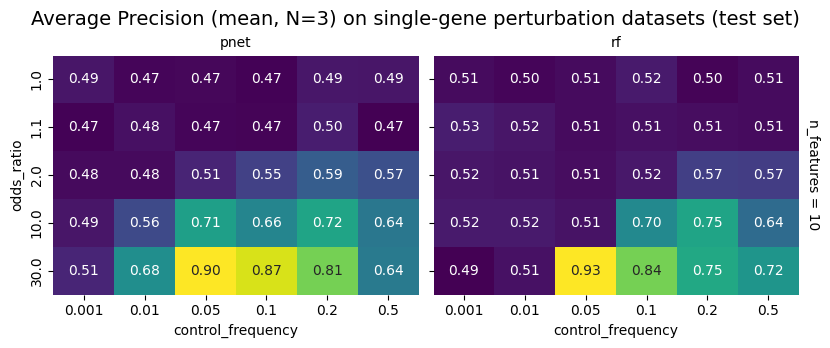

In [20]:
# matches feature importance plots in shape and style
# adding x-axis labels to all
eval_set = "test"
# filter to n_features 
df_avg_to_plot = df_avg[df_avg["n_features"] == 10]

metric = f"{eval_set}_avg_precision" 

g = sns.FacetGrid(
    df_avg_to_plot,
    row="n_features",
    col="model_type",
    margin_titles=True,
    height=3.5,
    aspect=1.2
)

def draw_heatmap(data, **kwargs):
    pivoted = data.pivot(index="odds_ratio", columns="control_frequency", values=metric)
    sns.heatmap(pivoted, cmap="viridis", annot=True, fmt=".2f", cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)
g.set_titles(row_template="n_features = {row_name}", col_template="{col_name}")
g.set_axis_labels("control_frequency", "odds_ratio")
# Adjust spacing
g.figure.subplots_adjust(top=0.85, hspace=0.1)

g.figure.suptitle(
    f"Average Precision (mean, N=3) on single-gene perturbation datasets ({eval_set} set)",
    fontsize=14
)

# Ensure all x-axis tick labels are shown
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels())
    ax.tick_params(axis='x', labelbottom=True)

plt.show()


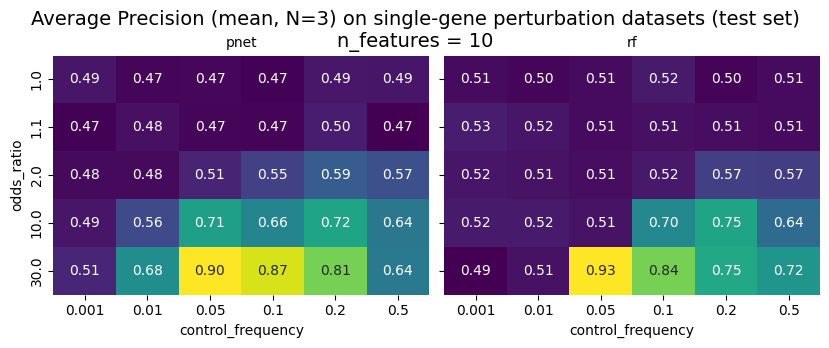

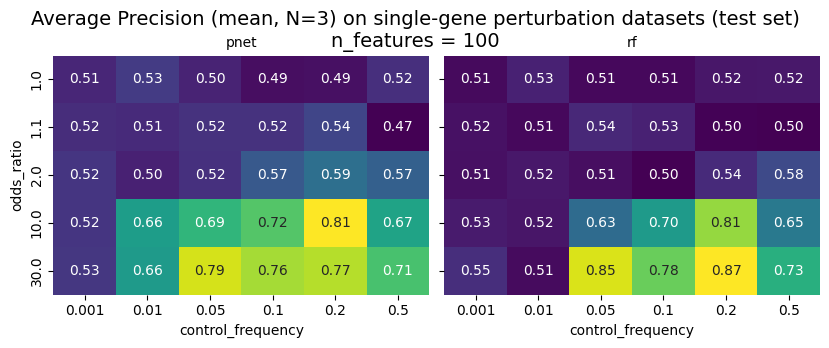

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

eval_set = "test"

for n_feat in sorted(df_avg["n_features"].unique()):
    subset = df_avg[df_avg["n_features"] == n_feat]

    g = sns.FacetGrid(
        subset,
        col="model_type",
        margin_titles=True,
        height=3.5,
        aspect=1.2
    )

    
    def draw_heatmap(data, **kwargs):
        pivoted = data.pivot(index="odds_ratio", columns="control_frequency", values=f"{eval_set}_avg_precision")
        sns.heatmap(pivoted, cmap="viridis", annot=True, fmt=".2f", cbar=False, **kwargs)

    g.map_dataframe(draw_heatmap)
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("control_frequency", "odds_ratio")
    g.figure.subplots_adjust(top=0.85)
    g.figure.suptitle(
        f"Average Precision (mean, N=3) on single-gene perturbation datasets ({eval_set} set)\nn_features = {n_feat}",
        fontsize=14
    )
    plt.show()


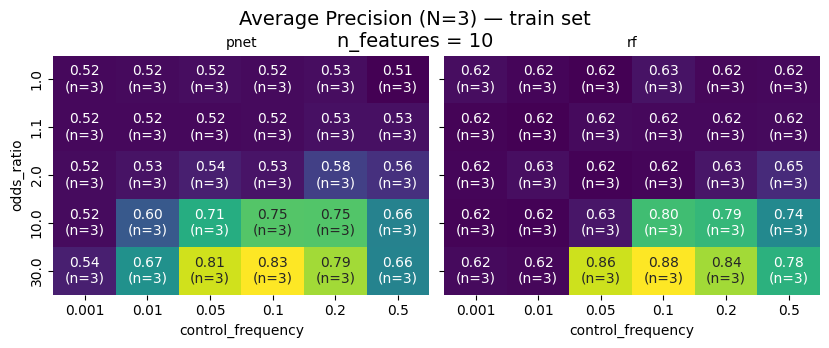

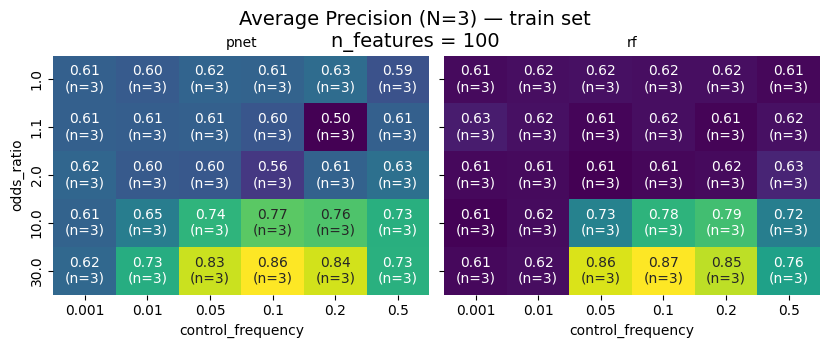

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

eval_set = "train"

for n_feat in sorted(df_avg["n_features"].unique()):
    subset = df_avg[df_avg["n_features"] == n_feat]

    g = sns.FacetGrid(
        subset,
        col="model_type",
        margin_titles=True,
        height=3.5,
        aspect=1.2
    )

    def draw(data, **kwargs):
        prec = data.pivot(index="odds_ratio", columns="control_frequency", values=f"{eval_set}_avg_precision")
        cnt = data.pivot(index="odds_ratio", columns="control_frequency", values="count")

        # Build annotation matrix
        annot = prec.copy().astype(str)
        for i in prec.index:
            for j in prec.columns:
                p = prec.loc[i, j]
                n = cnt.loc[i, j]
                if pd.notnull(p) and pd.notnull(n):
                    annot.loc[i, j] = f"{p:.2f}\n(n={int(n)})"
                else:
                    annot.loc[i, j] = ""

        sns.heatmap(prec, cmap="viridis", annot=annot, fmt="", cbar=False, **kwargs)

    g.map_dataframe(draw)
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("control_frequency", "odds_ratio")
    g.figure.subplots_adjust(top=0.85)
    g.figure.suptitle(
        f"Average Precision (N=3) — {eval_set} set\nn_features = {n_feat}",
        fontsize=14
    )
    plt.show()


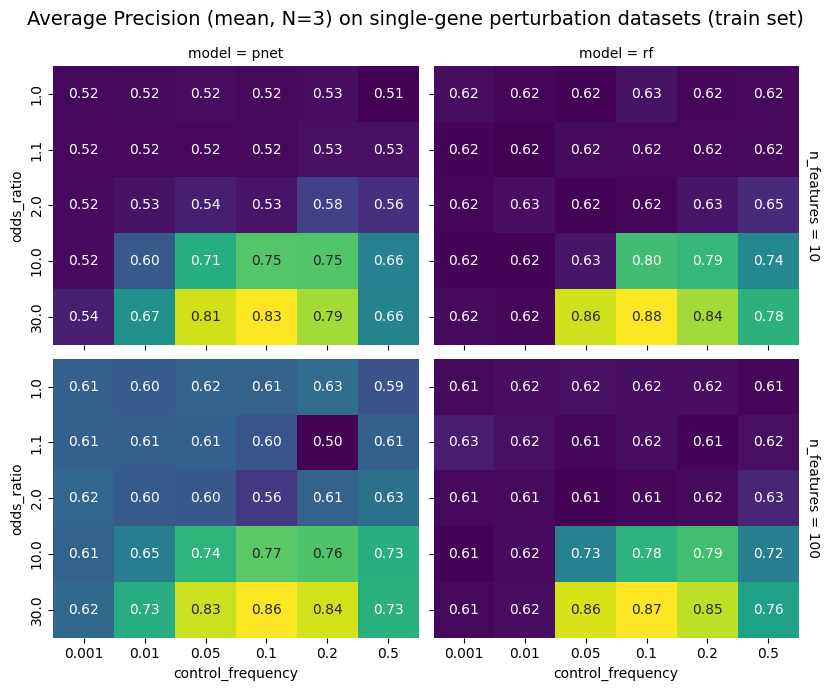

In [23]:
eval_set = "train"

# Option 1: faceted heatmaps
g = sns.FacetGrid(
    df_avg,
    row="n_features",
    col="model_type",
    margin_titles=True,
    height=3.5,
    aspect=1.2
)

def draw_heatmap(data, **kwargs):
    pivoted = data.pivot(index="odds_ratio", columns="control_frequency", values=f"{eval_set}_avg_precision")
    sns.heatmap(pivoted, cmap="viridis", annot=True, fmt=".2f", cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)
g.set_titles(row_template="n_features = {row_name}", col_template="model = {col_name}")
g.set_axis_labels("control_frequency", "odds_ratio")
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(f"Average Precision (mean, N=3) on single-gene perturbation datasets ({eval_set} set)", fontsize=14)
plt.show()


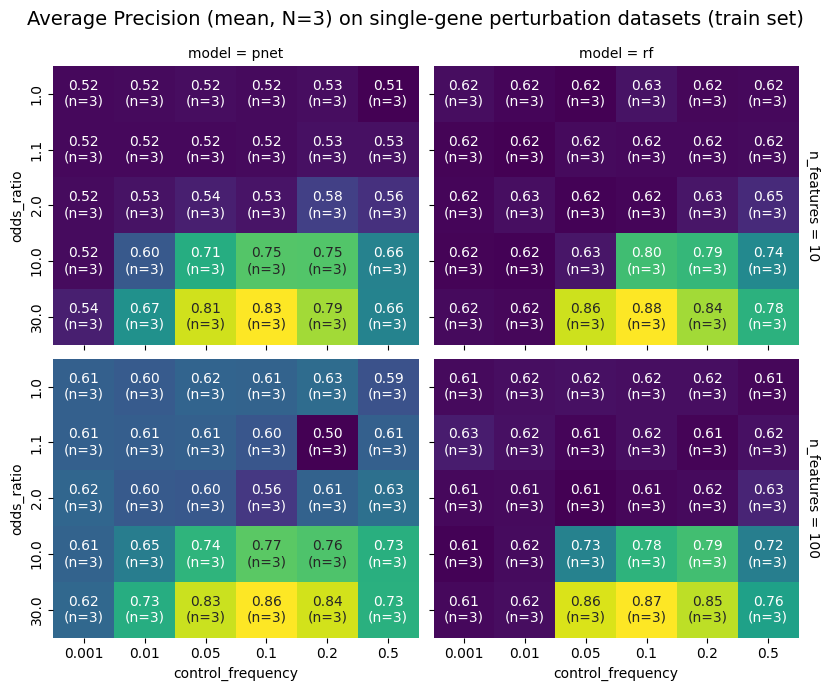

In [24]:
eval_set = "train"

# Option 1: faceted heatmaps
g = sns.FacetGrid(
    df_avg,
    row="n_features",
    col="model_type",
    margin_titles=True,
    height=3.5,
    aspect=1.2
)

def draw_heatmap(data, **kwargs):
    # Pivot the precision and count data
    precision = data.pivot(index="odds_ratio", columns="control_frequency", values=f"{eval_set}_avg_precision")
    counts = data.pivot(index="odds_ratio", columns="control_frequency", values="count")

    # Create combined annotation strings
    annot = precision.copy()
    annot = annot.applymap(str)
    for r in precision.index:
        for c in precision.columns:
            p = precision.loc[r, c]
            n = counts.loc[r, c]
            if pd.notnull(p) and pd.notnull(n):
                annot.loc[r, c] = f"{p:.2f}\n(n={int(n)})"
            else:
                annot.loc[r, c] = ""

    # Draw the heatmap with custom annotations
    sns.heatmap(precision, cmap="viridis", annot=annot, fmt="", cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)
g.set_titles(row_template="n_features = {row_name}", col_template="model = {col_name}")
g.set_axis_labels("control_frequency", "odds_ratio")
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(
    f"Average Precision (mean, N=3) on single-gene perturbation datasets ({eval_set} set)",
    fontsize=14
)
plt.show()


# How do P-NET feature rankings compare with ground truth?
In this 1D (single gene) perturbation setting, we spiked in a signal to a single gene. We chose "AR". Now, we will investigate the P-NET assigned rank of this gene

Plot: OR x control_frequency grid where the value is the rank (importance) assigned by the model to gene "AR".

In [ ]:
# get p-net gene importances
# convert to gene rank (sorted by descending absolute importance)
# get index of gene 'AR'

In [107]:
df

,model_type,n_features,odds_ratio,control_frequency,save_dir,perturbation_suffix,perturbed_data_dir,target_f,train_roc_auc_score,train_balanced_acc,...,validation_roc_auc_score,validation_balanced_acc,validation_avg_precision,test_roc_auc_score,test_balanced_acc,test_avg_precision,validation_feature_importances_path,validation_gene_importances_path,test_feature_importances_path,test_gene_importances_path
0,pnet,100,30.0,0.500,../../results/single_gene_perturbation_002/pne...,gene-AR_OR-30_ctrlFreq-0p5_caseFreq-0p9677_nFe...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.786141,0.732850,...,0.694949,0.693182,0.623444,0.756649,0.770168,0.697324,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...
1,pnet,100,30.0,0.500,../../results/single_gene_perturbation_002/pne...,gene-AR_OR-30_ctrlFreq-0p5_caseFreq-0p9677_nFe...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.781246,0.732850,...,0.734848,0.693182,0.689426,0.760195,0.770168,0.705296,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...
2,pnet,100,30.0,0.500,../../results/single_gene_perturbation_002/pne...,gene-AR_OR-30_ctrlFreq-0p5_caseFreq-0p9677_nFe...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.769838,0.732850,...,0.709596,0.693182,0.643269,0.777926,0.770168,0.731324,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...
3,pnet,100,10.0,0.500,../../results/single_gene_perturbation_002/pne...,gene-AR_OR-10_ctrlFreq-0p5_caseFreq-0p9091_nFe...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.773872,0.710412,...,0.627778,0.671717,0.556611,0.706560,0.686392,0.655270,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...
4,pnet,100,10.0,0.500,../../results/single_gene_perturbation_002/pne...,gene-AR_OR-10_ctrlFreq-0p5_caseFreq-0p9091_nFe...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.748757,0.710412,...,0.671717,0.671717,0.652062,0.718528,0.686392,0.671273,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...,../../results/single_gene_perturbation_002/pne...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,rf,10,1.1,0.001,../../results/single_gene_perturbation_002/rf_...,gene-AR_OR-1p1_ctrlFreq-0p001_caseFreq-0p0011_...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.935284,0.865537,...,0.512639,0.484075,0.501611,0.471162,0.419476,0.487280,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...
356,rf,10,1.1,0.001,../../results/single_gene_perturbation_002/rf_...,gene-AR_OR-1p1_ctrlFreq-0p001_caseFreq-0p0011_...,/mnt/disks/gmiller_data1/pnet_germline/process...,/mnt/disks/gmiller_data1/pnet_germline/process...,0.942089,0.872099,...,0.496461,0.518959,0.481175,0.523514,0.502440,0.508024,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...,../../results/single_gene_perturbation_002/rf_...
357,rf,10,1.0,0.001,..

## temporary: scratchwork to determine how to load feature importance data

In [13]:
perturbation_suffix = "gene-AR_OR-1_ctrlFreq-0p001_caseFreq-0p001_nFeatures-10"
perturbed_data_dir = "/mnt/disks/gmiller_data1/pnet_germline/processed/perturbed_genotype_datasets/p1000_somatic_mut/wandb-run-id-hvu4lf2q"
target_f = os.path.join(perturbed_data_dir, f"y_{perturbation_suffix}.csv")
target = pd.read_csv(target_f, index_col=0)
target

,is_met
Tumor_Sample_Barcode,
MO_1015,0
SC_9107,0
TCGA-EJ-7797,1
24854,0
TCGA-J4-A67K,0
...,...
P04-2641,1
AAPC-STID0000013388-Tumor-SM-2XU1Q,1
PROS10448-SUTC.01115084-SM-4JC6H,0


In [14]:


# want df with 1) y path 2) feature importances path 3) gene importances path 4) unique identifiers (odds ratio, control frequency, n_features, model_type)
df_feature_importance_paths = df[["save_dir", "target_f", "model_type", "n_features", "odds_ratio", "control_frequency"]].copy()

# filter to only model_type == "pnet"
df_feature_importance_paths = df_feature_importance_paths[df_feature_importance_paths["model_type"] == "pnet"].reset_index(drop=True)


# in "save_dir" column, replace "../../results/" with "/mnt/disks/gmiller_data1/pnet/results"
df_feature_importance_paths["save_dir"] = df_feature_importance_paths["save_dir"].str.replace("../../results/", "/mnt/disks/gmiller_data1/pnet/results/", regex=False)

eval_set = "test"
df_feature_importance_paths["feature_importances_path"] = df_feature_importance_paths.apply(lambda row: os.path.join(row["save_dir"], f"{eval_set}_gene_feature_importances.csv"), axis=1)
df_feature_importance_paths["gene_importances_path"] = df_feature_importance_paths.apply(lambda row: os.path.join(row["save_dir"], f"{eval_set}_gene_importances.csv"), axis=1)

# Add a unique group identifer column by joining together the unique identifiers: ["model_type", "n_features", "odds_ratio", "control_frequency"]
df_feature_importance_paths["group_identifier"] = df_feature_importance_paths.apply(
    lambda row: f"OR-{row['odds_ratio']}_ctrlFreq-{row['control_frequency']}_nFeatures-{row['n_features']}",
    axis=1
)


In [15]:
df_feature_importance_paths

,save_dir,target_f,model_type,n_features,odds_ratio,control_frequency,feature_importances_path,gene_importances_path,group_identifier
0,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,100,30.0,0.500,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-30.0_ctrlFreq-0.5_nFeatures-100
1,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,100,30.0,0.500,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-30.0_ctrlFreq-0.5_nFeatures-100
2,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,100,30.0,0.500,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-30.0_ctrlFreq-0.5_nFeatures-100
3,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,100,10.0,0.500,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-10.0_ctrlFreq-0.5_nFeatures-100
4,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,100,10.0,0.500,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-10.0_ctrlFreq-0.5_nFeatures-100
...,...,...,...,...,...,...,...,...,...
175,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,10,1.1,0.001,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-1.1_ctrlFreq-0.001_nFeatures-10
176,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,10,1.1,0.001,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-1.1_ctrlFreq-0.001_nFeatures-10
177,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,10,1.0,0.001,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-1.0_ctrlFreq-0.001_nFeatures-10
178,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet_germline/process...,pnet,10,1.0,0.001,/mnt/disks/gmiller_data1/pnet/results/single_g...,/mnt/disks/gmiller_data1/pnet/results/single_g...,OR-1.0_ctrlFreq-0.001_nFeatures-10


In [16]:
def load_feature_importances(importances_path):
    """
    Load feature importance data from a CSV file.

    Args:
        importances_path (str): Path to the feature importance file.

    Returns:
        pd.DataFrame: DataFrame of feature importances.
    """
    if not os.path.exists(importances_path):
        raise FileNotFoundError(f"File not found: {importances_path}")
    logger.debug(f"Loading feature importances from {importances_path}")
    return pd.read_csv(importances_path).set_index('Unnamed: 0')


def process_importances(imps, response_df):
    """
    Process feature importances by joining with response data and calculating differences between sample classes.
    This function computes the mean feature importances for each response class and then calculates the difference between them.
    The result is a Series of feature importance differences.

    Args:
        imps (pd.DataFrame): Feature importance DataFrame.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        pd.Series: Processed feature importance differences.
    """
    logger.debug(f"head of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().head()}")
    logger.debug(f"shape of imps.join(response_df).groupby('response').mean(): {imps.join(response_df).groupby('response').mean().shape}")
    return imps.join(response_df).groupby('response').mean().diff(axis=0).iloc[1]

def load_response_variable(response_path):
    response_df = pd.read_csv(response_path).set_index('Tumor_Sample_Barcode')
    # rename the column to 'response' for consistency
    response_df.rename(columns={"is_met": "response"}, inplace=True)
    return response_df

def process_feature_importances(df_feature_importance_paths, response_df_path_column='target_f', importance_path_column='feature_importances_path', group_identifier_column='group_identifier'):
    """
    Process feature importance data for multiple runs and group by dataset.

    Args:
        df_feature_importance_paths (pd.DataFrame): DataFrame with feature importance paths and dataset info.
        response_df (pd.DataFrame): Response variable DataFrame.

    Returns:
        tuple: Dictionaries of DataFrames for feature importances and ranks grouped by the input datasets used in the model.
    """
    imps_by_key = {}
    ranks_by_key = {}

    for _, row in df_feature_importance_paths.iterrows():
        try:
            # Load the response variable DataFrame from the specified path
            response_df = load_response_variable(row[response_df_path_column])
            # Load feature importances from the specified path
            imps = load_feature_importances(row[importance_path_column])
            processed_imps = process_importances(imps, response_df)
            ranks = processed_imps.abs().rank(ascending=False)

            key = row[group_identifier_column]
            imps_by_key.setdefault(key, []).append(processed_imps)
            ranks_by_key.setdefault(key, []).append(ranks)
        except FileNotFoundError as e:
            print(e)
            continue

    df_imps_by_key = {key: pd.DataFrame(imps_list) for key, imps_list in imps_by_key.items()}
    df_ranks_by_key = {key: pd.DataFrame(ranks_list) for key, ranks_list in ranks_by_key.items()}
    return df_imps_by_key, df_ranks_by_key



def extract_top_features_from_df(df_per_dataset, top_n=10, keep_smallest_n=True, index_label=None):
    """
    Extract the top N features by rank for each dataset.

    Args:
        df_per_dataset (dict): Dictionary containing feature-level pd DataFrames for each dataset.
        top_n (int): Number of top features to extract.
        keep_smallest_n (bool): Whether to sort in ascending order (lower rank is better).

    Returns:
        pd.DataFrame: DataFrame containing the top N features for each dataset.
    """
    top_features_df = pd.DataFrame()

    # Iterate over the dictionary to calculate top features
    for dataset, df in df_per_dataset.items():
        # Calculate the mean rank for each feature and select the top N
        top_features = df.mean(axis=0).sort_values(ascending=keep_smallest_n)[:top_n]
        # Add the top features as a column to the DataFrame
        top_features_df[dataset] = top_features.index

    # Set the index of the DataFrame to be 1 through top_n
    top_features_df.index = range(1, top_n + 1)

    if index_label is not None:
        top_features_df.index.name = index_label

    return top_features_df


In [17]:
logger.info("Get the feature importances and ranks for each dataset combination")
# response_df = load_response_variable()
# df_feature_importance_paths = fetch_feature_importance_paths(runs, GROUP_NAME)

# gene x modality
df_imps_by_key, df_ranks_by_key = process_feature_importances(df_feature_importance_paths)

# gene
df_imps_by_key, df_ranks_by_key = process_feature_importances(df_feature_importance_paths, importance_path_column='gene_importances_path')

2025-06-20 19:50:43 INFO     [__main__] Get the feature importances and ranks for each dataset combination


In [18]:
top_10_features_by_rank = extract_top_features_from_df(df_ranks_by_key, top_n=10, keep_smallest_n=True, index_label="rank")
top_10_features_by_rank

,OR-30.0_ctrlFreq-0.5_nFeatures-100,OR-10.0_ctrlFreq-0.5_nFeatures-100,OR-2.0_ctrlFreq-0.5_nFeatures-100,OR-1.1_ctrlFreq-0.5_nFeatures-100,OR-1.0_ctrlFreq-0.5_nFeatures-100,OR-30.0_ctrlFreq-0.2_nFeatures-100,OR-10.0_ctrlFreq-0.2_nFeatures-100,OR-2.0_ctrlFreq-0.2_nFeatures-100,OR-1.1_ctrlFreq-0.2_nFeatures-100,OR-1.0_ctrlFreq-0.2_nFeatures-100,...,OR-30.0_ctrlFreq-0.01_nFeatures-10,OR-10.0_ctrlFreq-0.01_nFeatures-10,OR-2.0_ctrlFreq-0.01_nFeatures-10,OR-1.1_ctrlFreq-0.01_nFeatures-10,OR-1.0_ctrlFreq-0.01_nFeatures-10,OR-30.0_ctrlFreq-0.001_nFeatures-10,OR-10.0_ctrlFreq-0.001_nFeatures-10,OR-2.0_ctrlFreq-0.001_nFeatures-10,OR-1.1_ctrlFreq-0.001_nFeatures-10,OR-1.0_ctrlFreq-0.001_nFeatures-10
rank,,,,,,,,,,,,,,,,,,,,,
1,AR,AR,AR,AR,AR,AR,AR,AR,NCBP1,AR,...,AR,AR,PPAT,NDST3,NDST3,AR,AR,NDST3,AR,PPAT
2,NCBP1,NPY2R,EGFR,EGFR,EGFR,ARNT,NCBP1,FOXE3,EGFR,EGFR,...,NDST3,NDST3,NDST3,KIAA1462,PPAT,NDST3,PPAT,PPAT,NDST3,NDST3
3,ZNF662,ZNF662,NPY2R,AFAP1L2,FOXE3,ZNF662,ZNF662,ARNT,ARNT,NCBP1,...,PPAT,PPAT,KIAA1462,PPAT,KIAA1462,PPAT,NDST3,KIAA1462,KIAA1462,KIAA1462
4,EGFR,ARNT,NCBP1,NCBP1,ARNT,WNK2,EGFR,EGFR,TRRAP,GPN1,...,KIAA1462,KIAA1462,COG5,OCM2,COG5,KIAA1462,KIAA1462,NADK,PPAT,OCM2
5,ARNT,NCBP1,RPS6KA4,GPN1,NCBP1,EGFR,TRRAP,GPN1,AR,FOXE3,...,COG5,COG5,ZBTB6,COG5,NADK,ZBTB6,NADK,COG5,RBM22,RBM22
6,TRRAP,EGFR,NTRK3,NPY2R,GPN1,NCBP1,NPY2R,NPY2R,NPR2,ARNT,...,RBM22,OR13C4,OCM2,OR13C4,OR13C4,OR13C4,RBM22,AR,COG5,NADK
7,RPS6KA4,DPYSL4,FOXE3,NTRK3,AFAP1L2,CABP2,RPTN,AFAP1L2,NTRK3,AFAP1L2,...,OCM2,RBM22,RBM22,ZBTB6,RBM22,COG5,ZBTB6,OCM2,OCM2,AR
8,RPRD2,RPTN,GPN1,KLF11,KLF11,NTRK3,WNK2,NCBP1,NPY2R,KLF11,...,ZBTB6,OCM2,AR,RBM22,ZBTB6,OCM2,OR13C4,ZBTB6,ZBTB6,ZBTB6
9,NTRK3,RPS6KA4,AFAP1L2,FOXE3,NPY2R,TRRAP,ARNT,RPRD2,FOXE3,NPY2R,...,OR13C4,NADK,OR13C4,AR,AR,NADK,COG5,OR13C4,OR13C4,COG5


In [19]:
# Extract AR importances and ranks from the processed dicts
AR_records = []

for key, df_imp in df_imps_by_key.items():
    mean_imp = df_imp.mean()
    mean_rank = df_ranks_by_key[key].mean()
    
    if "AR" in mean_imp:
        AR_records.append({
            "group_identifier": key,
            "AR_importance": mean_imp["AR"],
            "AR_absolute_importance": abs(mean_imp["AR"]),
            "AR_rank": mean_rank["AR"]
        })

df_AR = pd.DataFrame(AR_records)
# Merge AR stats into the plotting dataframe
df_plot = df_feature_importance_paths.merge(df_AR, on="group_identifier", how="left")
df_plot_avg = df_plot.groupby(group_by_cols, as_index=False).mean()


In [20]:
df_plot_avg

,model_type,n_features,odds_ratio,control_frequency,AR_importance,AR_absolute_importance,AR_rank
0,pnet,10,1.0,0.001,0.000000,0.000000,7.000000
1,pnet,10,1.0,0.010,0.000000,0.000000,7.000000
2,pnet,10,1.0,0.050,-0.000035,0.000035,3.333333
3,pnet,10,1.0,0.100,-0.000747,0.000747,1.000000
4,pnet,10,1.0,0.200,-0.000750,0.000750,2.333333
5,pnet,10,1.0,0.500,-0.007180,0.007180,2.333333
6,pnet,10,1.1,0.001,-0.004884,0.004884,1.333333
7,pnet,10,1.1,0.010,0.000000,0.000000,7.000000
8,pnet,10,1.1,0.050,0.000019,0.000019,1.333333
9,pnet,10,1.1,0.100,-0.001625,0.001625,1.666667


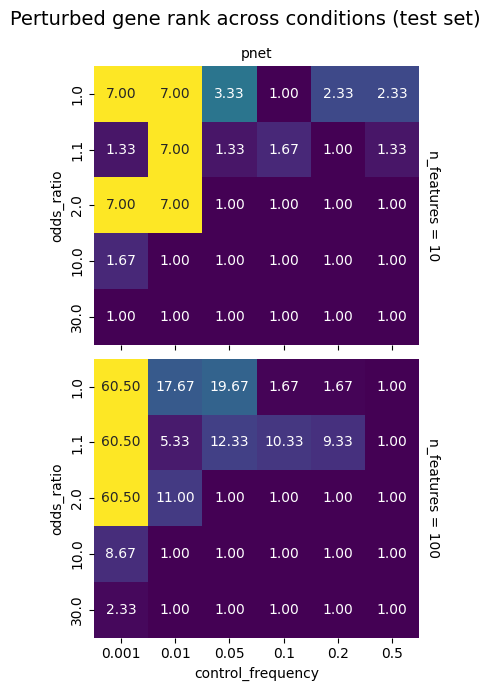

In [35]:
metric = "AR_rank"  # or "AR_rank", "AR_absolute_importance", "AR_importance"
eval_set = "test"  # just reusing this for the title context

g = sns.FacetGrid(
    df_plot_avg,
    row="n_features",
    col="model_type",
    margin_titles=True,
    height=3.5,
    aspect=1.2
)

def draw_heatmap(data, **kwargs):
    pivoted = data.pivot(index="odds_ratio", columns="control_frequency", values=metric)
    sns.heatmap(pivoted, cmap="viridis", annot=True, fmt=".2f", cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)
g.set_titles(row_template="n_features = {row_name}", col_template="{col_name}")
g.set_axis_labels("control_frequency", "odds_ratio")
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(f"Perturbed gene {'importance' if metric == 'AR_importance' else 'rank'} across conditions ({eval_set} set)", fontsize=14)
plt.show()


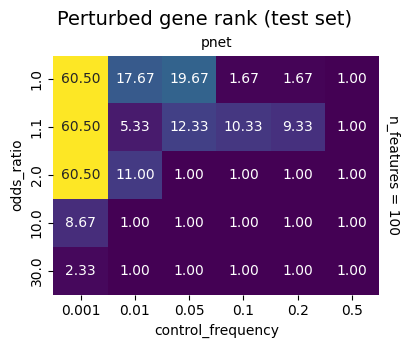

In [46]:
# adding x-axis labels to all

metric = "AR_rank"  # or "AR_rank", "AR_absolute_importance", "AR_importance"
eval_set = "test"
df_plot_avg_tmp = df_plot_avg[df_plot_avg["n_features"] == 100]


g = sns.FacetGrid(
    df_plot_avg_tmp,
    row="n_features",
    col="model_type",
    margin_titles=True,
    height=3.5,
    aspect=1.2
)

def draw_heatmap(data, **kwargs):
    pivoted = data.pivot(index="odds_ratio", columns="control_frequency", values=metric)
    sns.heatmap(pivoted, cmap="viridis", annot=True, fmt=".2f", cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)
g.set_titles(row_template="n_features = {row_name}", col_template="{col_name}")
g.set_axis_labels("control_frequency", "odds_ratio")
# Adjust spacing
g.figure.subplots_adjust(top=0.85, hspace=0.1)

g.figure.suptitle(
    f"Perturbed gene {'importance' if metric == 'AR_importance' else 'rank'} ({eval_set} set)",
    fontsize=14
)

# Ensure all x-axis tick labels are shown
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels())
    ax.tick_params(axis='x', labelbottom=True)

plt.show()
